In [80]:
import numpy as np
from collections import OrderedDict
import math
import numpy as np
import pandas as pd
import pymeasure
from time import sleep, time
from matplotlib import pyplot as plt
from matplotlib import style
from datetime import datetime
from pymeasure.instruments.keithley import Keithley2400
from pymeasure.instruments.keithley import Keithley2000
import matplotlib.cm as cm
from glob import glob
import os
import sys

In [73]:
myKeithley = Keithley2400(4)

In [74]:
myKeithley.source_current = 0

In [75]:
# myKeithley.adapter.connection.timeout
def ramp_to_current_and_confirm(desiredcurrent,stepsize = 0.5,pause=0.2):
    print(f"setting current to {desiredcurrent}")
    myKeithley.ramp_to_current(desiredcurrent)

    nowishCurrent = np.nan
    # nowishVoltage2 = np.nan

    while not( math.isclose( nowishCurrent,  desiredcurrent, rel_tol=0.001) ):  #, abs_tol=1e-7
        try:
            nowishCurrent = myKeithley.source_current
        except:
            print("it didn't like it")

        print(f"Current at {nowishCurrent}")
        sleep(2)
    
    print(f"Finalized current at {myKeithley.source_current}")

In [76]:
# Imin, Imax, Istep = -700e-6, 700e-6, 10e-6
# IdataPoints= int(np.absolute(Imax-Imin)/Istep)+1
# currents = np.linspace(Imin,Imax,num=IdataPoints).tolist()

#remove point in list closest to 0
def remove_middle_element(lst):
    lst.remove(min(lst, key=lambda x:abs(x-0)))
    return lst

# currents = remove_middle_element(currents)

In [77]:
def IV_rxx(Imin, Imax, Istep, average,file_path,sample_name):
    IdataPoints= int(np.absolute(Imax-Imin)/Istep)+1
    currents = np.linspace(Imin,Imax,num=IdataPoints).tolist()
    currents = remove_middle_element(currents)
    data = OrderedDict()
    data['I'], data['V'] = [], []
    filename = file_path+'IV'+sample_name+'I_min'+str(Imin)+'max'+str(Imax)+'.csv'
    # currents.remove(0.0)

    for c in currents:
        print(c)
        ramp_to_current_and_confirm(c)
        data['I'].append(c)
        voltage = myKeithley.voltage
        print('Voltage : ' + str(voltage) + 'V')
        data['V'].append(voltage)
        
        plt.plot(data['I'], data['V'])
        plt.xlabel('Current',fontsize=18)
        plt.ylabel('Voltage',fontsize=18)
        
        print(f'Measurement done for current : {c} ')
        datafram = pd.DataFrame({ 'I': np.transpose(data['I']), 'V':np.transpose(data['V'])})
        #save dataframe to csv file in the same path and file name
        datafram.to_csv(filename,index=False)

    #reset voltage after experiment
    myKeithley.ramp_to_current(0)


-0.0007
setting current to -0.0007
Current at -0.0007
Finalized current at -0.0007
Voltage : -0.3817833V
Measurement done for current : -0.0007 
-0.00069
setting current to -0.00069
Current at -0.00069
Finalized current at -0.00069
Voltage : -0.3762698V
Measurement done for current : -0.00069 
-0.00068
setting current to -0.00068
Current at -0.00068
Finalized current at -0.00068
Voltage : -0.3707307V
Measurement done for current : -0.00068 
-0.00067
setting current to -0.00067
Current at -0.00067
Finalized current at -0.00067
Voltage : -0.3651864V
Measurement done for current : -0.00067 
-0.00066
setting current to -0.00066
Current at -0.00066
Finalized current at -0.00066
Voltage : -0.3596428V
Measurement done for current : -0.00066 
-0.00065
setting current to -0.00065
Current at -0.00065
Finalized current at -0.00065
Voltage : -0.3540937V
Measurement done for current : -0.00065 
-0.0006399999999999999
setting current to -0.0006399999999999999
Current at -0.00064
Finalized current at

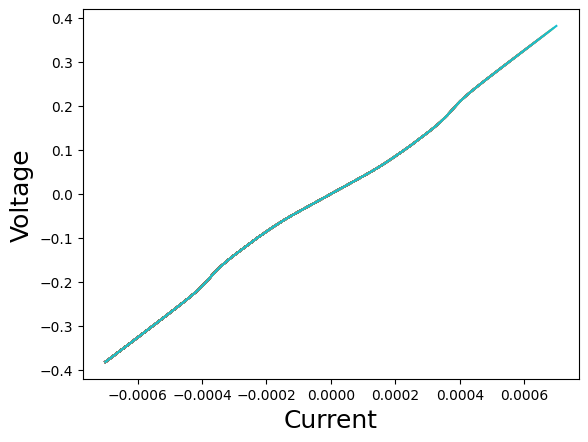

In [83]:
%matplotlib inline
file_path=r'C:\Users\Ralph Group\Documents\Data\Orion\WisconsinBPBOPtCo\VICurve\4.47K'
sample_name='4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.0T__-46.32deg__'
average = 1
IV_rxx(-700e-6, 700e-6, 10e-6, average,file_path,sample_name)